In [1]:
import sys
sys.path.insert(0, '../Modules/')
import numpy as np
import torch
from sklearn.decomposition import PCA
from index_set import index_set
from families import JacobiPolynomials
from HAlphaBasisCompressor import HAlphaBasisCompressor
from OperatorLearningPlotter import OperatorLearningPlotter
from Empirical_Operator_WLS import Empirical_Operator_WLS


### Dimension Reduction parameters
nPCA_Max =  750              # Maximum number of PCA modes allowed
PCA_Threshold = 0.995        # Amount of energy to retain in input space
alpha = 0                    # Sobolev Parameter for output space: 0 = L^2, 1 = H^1, etc.  
HAlpha_Threshold = 0.999     # Amount of energy to retain in output data


### Scale input data to lie in [-1,1]: 
normalization = 'uniform'    # Scale all input data uniformly, to maintain relative magnitudes

### Load data 
# Spatial data is on 128 x 128 grid
train_dat = torch.load('Spatial_Data/nsforcing_train_128.pt', weights_only=True)
test_dat  = torch.load('Spatial_Data/nsforcing_test_128.pt', weights_only=True )
X_train_grid = train_dat['x'].numpy()
Y_train_grid = train_dat['y'].numpy()
X_test_grid  = test_dat['x'].numpy()
Y_test_grid  = test_dat['y'].numpy()

### TRAIN ON TEST DATA ALSO TO FIND 'GOOD' INDEX SET  # This will be wrt a different basis later!
#X_train_grid = np.vstack([X_test_grid, X_train_grid])
#Y_train_grid = np.vstack([Y_test_grid, Y_train_grid])

# Reshape X grid data to vector for PCA
X_train = X_train_grid.reshape(X_train_grid.shape[0],-1)
X_test  = X_test_grid.reshape(X_test_grid.shape[0], -1) 

# Adaptively choose number of PCA coeffcients 
pca = PCA(n_components = nPCA_Max)
pca.fit(X_train)
nPCA_X = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), PCA_Threshold)+1

# Preform PCA to lower dimensionality
pca_X = PCA(n_components=nPCA_X)
input_data_raw = pca_X.fit_transform(X_train)
input_data_raw_test = pca_X.transform(X_test)

# Scale input coefficients to lie in [-1,1] for Jacobi Polynomial Domain 
if normalization == 'uniform':
    linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test))))
    input_data = input_data_raw / linf
    input_test = input_data_raw_test / linf

elif normalization == 'entrywise': 
    input_data = np.zeros_like(input_data_raw)
    input_test = np.zeros_like(input_data_raw_test)
    for col in range(nPCA_X):
        linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test)))[:,col])
        input_data[:,col] = input_data_raw[:,col]/linf
        input_test[:,col] = input_data_raw_test[:,col]/linf
else:
    raise ValueError("Normalization must be either 'uniform' for 'entrywise'")

# Project Y Data onto H^alpha subspace:
compressor = HAlphaBasisCompressor(N=Y_train_grid.shape[1], threshold=HAlpha_Threshold, alpha = alpha)
compressor.fit(Y_train_grid) 
output_data = np.array([compressor.project(snapshot) for snapshot in Y_train_grid])
output_test = np.array([compressor.project(snapshot) for snapshot in Y_test_grid])

### Fit Jacobi Parameters Defining Measure on Input Space by Matching Empirical Variance 
#   NOTE: For symmetric beta distribution, Var_a = 1/(2a + 3)
VarX = np.var(input_data, axis = 0)
VarX_safe = np.clip(VarX, 1e-10, None)  # avoid blow up for near zero variance
jParams = ((1/VarX) - 3)/2   


In [9]:
HC_Param = 115
max_poly_indx = 20           
anisotropic = True               


idx_weights = 0.8*(pca_X.singular_values_ / pca_X.singular_values_[0]) if anisotropic else np.ones(nPCA_X)
#idx_weights = (pca_X.singular_values_ / pca_X.singular_values_[0])  if anisotropic else np.ones(nPCA_X)
PolyIdxs = index_set(d = nPCA_X, param = HC_Param, max_index = max_poly_indx, weights = idx_weights, max_size = 25_000, type = 'hc' )
N = PolyIdxs.shape[0]
M = int(N*np.log(N))
N

9769

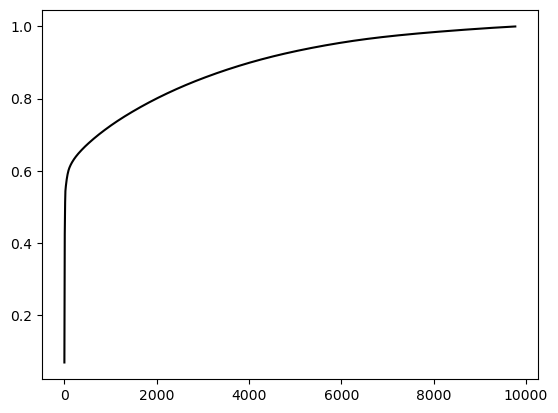

In [10]:
wls_operator = Empirical_Operator_WLS(
    input_data = input_data, 
    output_data = output_data, 
    index_set = PolyIdxs, 
    jacobi_params = jParams, 
    induced = True) 
wls_operator.fit(M)

C = wls_operator.operator_coeffs
row_energies = np.sum(np.abs(C)**2, axis = 1)
sorted_energies = row_energies[np.argsort(row_energies)[::-1]]
retained_energy = np.cumsum(sorted_energies) / np.sum(sorted_energies)
np.save("Data/H0_sorted_index_set.npy",PolyIdxs[np.argsort(row_energies)[::-1]])
np.save("Data/retained_energy_idx_set.npy", retained_energy)

import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.plot(np.arange(retained_energy.shape[0]), retained_energy, "k-", markersize = 0.6)
ax.set()
plt.show()